# Grid Convergence for the TRTS 
This is an example of a grid conergence study using a Delft3d case on the Tanana River Test Site (TRTS) located in Nenana, Alaska. The IEC 62600-301 specifies that the grid should be refined so the Grid convergence Idex (GCI) is less than 6% for water level and depth-averaged current speed. The TRTS Delft3D grid used a retagular grid squar grid cells. This example will plot the depth-averaged current speed and water level for the TRTS model with a 8m, 4m, 2m and 1m grid cell edge length.

*** Note: should I add more into about the model or a picture or plot of the total area?

First the Delft3d moduel for MHKiT is imported along with sevreal other python packages. 

In [12]:
import scipy.interpolate as interp
import matplotlib.pyplot as plt
from mhkit.river.io import d3d
import pandas as pd
import numpy as np
import netCDF4

## Load data

### Load Centerline Points

***Note: it might be useful to include how I got the centerline points althoug I would alos have to import the shape of the river ***

The centerline points are found using the shape of the rive and the x and y in UTM cordinates are saved in a CSV file. This CSV file is read in and the first 5 rows are shown.

In [2]:
# Load the CSV file into a DataFrame
centerline_points = pd.read_csv('centerline_points.csv')

# Display the first few rows of the DataFrame
print(centerline_points.head())

               x             y
0  400929.336889  7.161512e+06
1  400930.988201  7.161505e+06
2  400932.639512  7.161499e+06
3  400934.290824  7.161493e+06
4  400935.942135  7.161487e+06


### Load Delft3d Data

Load the Delft3D model output for all the grid lenghs: 8m, 4m, 2m, and 1m. 


In [ ]:
# Load the NetCDF file
dataset_8m_raw = netCDF4.Dataset('FlowFM_map_8m-test.nc') #FlowFM_8m_map.nc
## Test xarray input #dataset_8m_xr = xr.open_dataset('FlowFM_8m_map.nc')
#dataset_4m_raw = netCDF4.Dataset('')
#dataset_2m_raw = netCDF4.Dataset('')
#dataset_1m_raw = netCDF4.Dataset('')



## Depth Averaged Current Speed

The MHKiT Delft3D (D3D) function `get_all_data_points` is used to import the variable `mesh2d_ucmaga` which is the Flow element center depth-averaged velocity magnitude. The `get_all_data_points` function outputs the coresponding x and y cordinates along with the water depth, water level and time step. The time step defalts to -1 or the last time step in the simulation. The datafram for the 8m grid length resolution is shown.

In [24]:
variable="mesh2d_ucmaga"
dataset_8m =d3d.get_all_data_points(dataset_8m_raw, variable)
#dataset_4m =d3d.get_all_data_points(dataset_4m_raw, variable)
#dataset_2m =d3d.get_all_data_points(dataset_2m_raw, variable)
#dataset_1m =d3d.get_all_data_points(dataset_1m_raw, variable)
dataset_8m

,x,y,waterdepth,waterlevel,mesh2d_ucmaga,time
index,,,,,,
0,400993.370690,7.160784e+06,0.0,124.629313,0.0,86400.0
1,401000.888231,7.160787e+06,0.0,124.601929,0.0,86400.0
2,400990.634529,7.160792e+06,0.0,124.629313,0.0,86400.0
3,401008.405772,7.160790e+06,0.0,124.557983,0.0,86400.0
4,400998.152070,7.160795e+06,0.0,124.655420,0.0,86400.0
...,...,...,...,...,...,...
10277,401116.829970,7.161638e+06,0.0,121.468827,0.0,86400.0
10278,401106.576268,7.161643e+06,0.0,120.626144,0.0,86400.0
10279,401124.347511,7.161641e+06,0.0,122.397965,0.0,86400.0


### Interpolate Velocity onto Centerline 

Scipy's interp griddata is used to interpolate the velocity data onto the centerline points. A for loop is used to iterate over the 4 grid resolutions. 

In [20]:
grid_resolutions = ['8m']# '4m', '2m', '1m']
center_line_velocity = {}

for resolution in grid_resolutions:
    dataset = globals()[f'dataset_{resolution}']
    center_line_velocity[resolution] = interp.griddata(
        dataset[["x", "y"]],
        dataset[variable],
        centerline_points[["x", "y"]],
    )



KeyError: '4m'

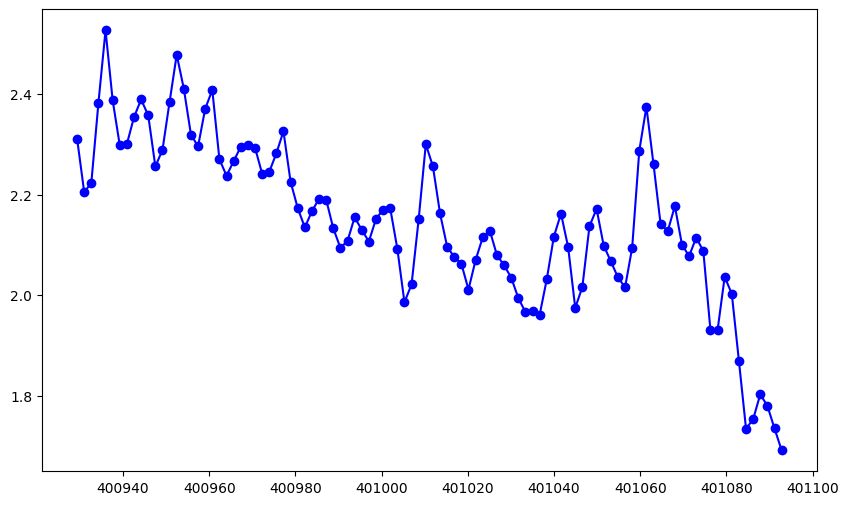

In [ ]:
# Plot Depth Averaged Velocity over Centerline
plt.figure(figsize=(10, 6))
plt.plot(centerline_points.x, center_line_velocity['8m'], marker='o', linestyle='-', color='b',label="8m_grid")
plt.plot(centerline_points.x, center_line_velocity['4m'], marker='o', linestyle='-', color='b',label="4m_grid")
plt.plot(centerline_points.x, center_line_velocity['2m'], marker='o', linestyle='-', color='b',label="2m_grid")
plt.plot(centerline_points.x, center_line_velocity['1m'], marker='o', linestyle='-', color='b',label="1m_grid")
plt.xlabel('UTM x')
plt.ylabel('Depth Averaged Velocity (m/s)')
plt.grid(True)
plt.show()

## Waterlevel

The waterlevel data was already obtrained from the depth averaged velocity dataframe. The same for loop process is used to interpolate all 4 grid sizes onto the centerline poins.The results are then ploted. 

In [ ]:
grid_resolutions = ['8m']# '4m', '2m', '1m']
center_line_velocity = {}

for resolution in grid_resolutions:
    dataset = globals()[f'dataset_{resolution}']
    center_line_waterlevel[resolution] = interp.griddata(
        dataset[["x", "y"]],
        dataset["waterlevel"],
        centerline_points[["x", "y"]],
    )

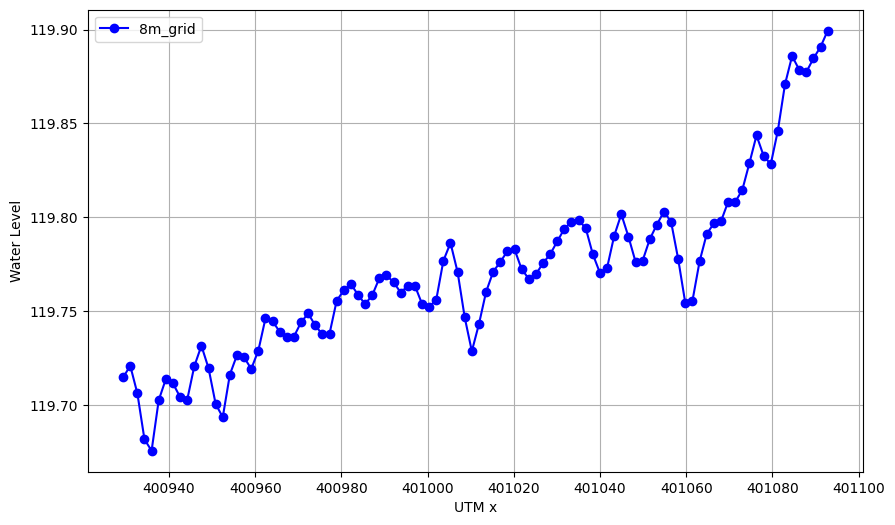

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(centerline_points.x, center_line_waterlevel['8m'], marker='o', linestyle='-', color='b', label="8m_grid")
plt.plot(centerline_points.x, center_line_waterlevel['4m'], marker='o', linestyle='-', color='b', label="4m_grid")
plt.plot(centerline_points.x, center_line_waterlevel['2m'], marker='o', linestyle='-', color='b', label="2m_grid")
plt.plot(centerline_points.x, center_line_waterlevel['1m'], marker='o', linestyle='-', color='b', label="1m_grid")
plt.xlabel('UTM x')
plt.ylabel('Water Level')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
def calculate_grid_convergence_index(fine_grid, coarse_grid, refinement_ratio,factor_of_safety=1.25, order=2):
    """
    Calculate the Grid Convergence Index (GCI) between two grid sizes. https://www.grc.nasa.gov/WWW/wind/valid/tutorial/spatconv.html

    Parameters
    ----------
    fine_grid: numpy.ndarray
        Results from the finer grid.
    coarse_grid: numpy.ndarray
        Results from the coarser grid.
    refinement_ratio: float 
        Refinement ratio between the grids.
    order: int
        Order of accuracy (default is 2).

    Returns
    -------
    gci: float
        Grid Convergence Index (GCI).
    """
    # Calculate the approximate relative error
    error = np.abs((fine_grid - coarse_grid) / fine_grid)

    # Calculate the GCI
    gci = (factor_of_safety * error) / (refinement_ratio**order - 1)
    return gci

# Example usage
# Assuming `center_line_velocity` contains velocity data for different grid resolutions
grid_resolutions = ['8m', '4m', '2m', '1m']
refinement_ratios = [2, 2, 2]  # Refinement ratio between consecutive grids

gci_results = {}
for i in range(len(grid_resolutions) - 1):
    fine = center_line_velocity[grid_resolutions[i + 1]]
    coarse = center_line_velocity[grid_resolutions[i]]
    refinement_ratio = refinement_ratios[i]
    gci_results[f"{grid_resolutions[i]}-{grid_resolutions[i + 1]}"] = calculate_grid_convergence_index(
        fine, coarse, refinement_ratio
    )

# Print GCI results
for key, value in gci_results.items():
    print(f"GCI between {key}: {value}")

KeyError: '4m'